In [34]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import pandas as pd
import sys
import igraph as ig
import pickle

sys.path.append('/Users/artemilin/Work/projects/scCandT/toolkit-project')
import src as scit

In [18]:
adata2 = ad.read_h5ad("../h5ad/ct_glue_postGO_anno_final_final_250310.h5ad")

In [19]:
scit.set_defaults(figsize=(7,6))

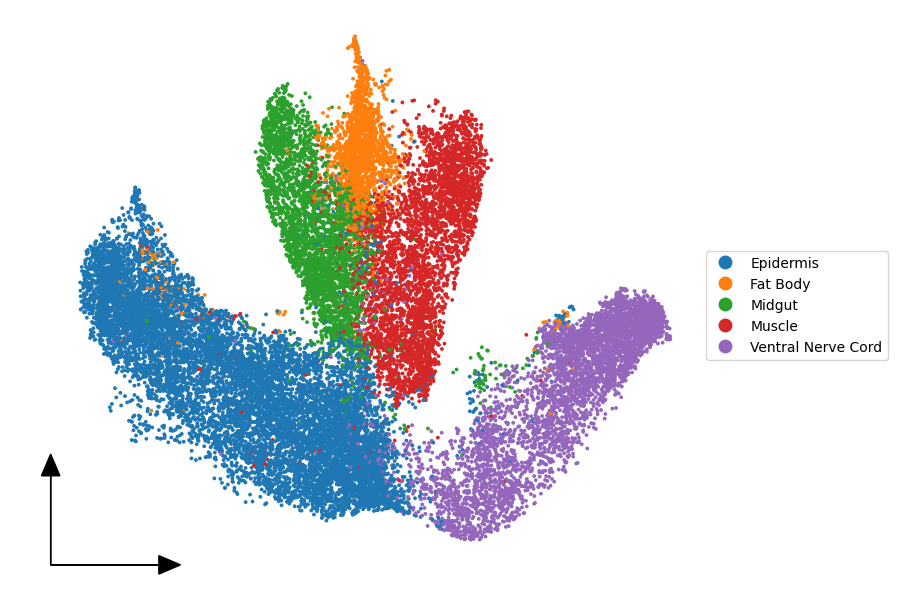

In [20]:
scit.pl.embedding2d(adata2, "X_umap", "label_own")

In [10]:
pres = pd.read_table("../bed/Release6_dm6_PREs.bed", sep = '\t', header= None)
pres.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22250 entries, 0 to 22249
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       22250 non-null  object
 1   1       22250 non-null  int64 
 2   2       22250 non-null  int64 
 3   3       22250 non-null  object
dtypes: int64(2), object(2)
memory usage: 695.4+ KB


In [14]:
chrom = pres[0]
cstart = pres[1].astype(str)
cend = pres[2].astype(str)
presloc = chrom + ":" + cstart + "-" + cend
presloc = presloc.tolist()
presloc

['chr2L:4962-7474',
 'chr2L:42399-43124',
 'chr2L:65992-66705',
 'chr2L:66768-67706',
 'chr2L:95409-96693',
 'chr2L:98256-99322',
 'chr2L:107969-108576',
 'chr2L:121342-121987',
 'chr2L:139925-140864',
 'chr2L:142243-143066',
 'chr2L:150131-151312',
 'chr2L:158718-159777',
 'chr2L:160435-161663',
 'chr2L:166048-167161',
 'chr2L:172894-173876',
 'chr2L:175048-175946',
 'chr2L:176880-178061',
 'chr2L:186037-186709',
 'chr2L:196102-196668',
 'chr2L:215741-216483',
 'chr2L:219424-220798',
 'chr2L:221307-223492',
 'chr2L:233092-234228',
 'chr2L:240068-240789',
 'chr2L:242038-244094',
 'chr2L:245415-247290',
 'chr2L:248704-249981',
 'chr2L:250099-251076',
 'chr2L:252220-252923',
 'chr2L:266791-267826',
 'chr2L:270126-271147',
 'chr2L:274268-274982',
 'chr2L:275336-276159',
 'chr2L:299850-300977',
 'chr2L:305905-306785',
 'chr2L:309672-311068',
 'chr2L:313416-314164',
 'chr2L:314544-315572',
 'chr2L:316351-317746',
 'chr2L:319042-319784',
 'chr2L:322023-323095',
 'chr2L:324710-325453',
 'chr2

In [30]:
adata2.obsm['acet_imp'].shape

(26346, 12585)

In [31]:
adata2

AnnData object with n_obs × n_vars = 26346 × 24130
    obs: 'batch', 'meth_total_counts', 'meth_log_total_counts', 'acet_total_counts', 'acet_log_total_counts', 'exclude', 'timep', 'leiden_ms', 'label', 'leiden_glue', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'copied_data', 'leiden', 'label_own', 'outside'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'chr', 'start', 'end'
    uns: 'colors_dict', 'gene_names_acet_binary', 'gene_names_acet_imp', 'gene_names_meth_binary', 'gene_names_meth_imp'
  

In [35]:
with open("../go_reg/gene-names.pickle", "rb") as f:
    names = pickle.load(f)

In [48]:
names

['gfzf',
 'sisRNA:CR46358',
 'Osi24',
 'msps',
 'CG6013',
 'lncRNA:CR44091',
 'CG8043',
 'CG6753',
 'lncRNA:CR45911',
 'CG42788',
 'Atg17',
 'CG15525',
 'ATPsynE',
 'CG44014',
 'CG14329',
 'DhpD',
 'CG15923',
 'asRNA:CR46134',
 'Sdr',
 'CG11768',
 'CG33093',
 'CG5815',
 'Ect3',
 'CG14715',
 'CG15025',
 'Manf',
 'mRpS18A',
 'CG5023',
 'CG6254',
 'Saf-B',
 'snoRNA:Psi28S-291',
 'CG7910',
 'pinta',
 'Task7',
 'CG4367',
 'trus',
 'scaRNA:MeU2-C41',
 'snRNP-U1-C',
 'CG6503',
 'CG31106',
 'CG12268',
 'CG11722',
 'Wsck',
 'asRNA:CR45028',
 'lncRNA:CR45901',
 'CG11892',
 'unk',
 'GluRIIE',
 'Sec15',
 'HP1c',
 'Spase22-23',
 'Taf12',
 'Naa80',
 'topi',
 'CAH9',
 'CG6980',
 'CG4408',
 'Ugt35C1',
 'CG14543',
 'B9d1',
 'GluProRS',
 'Fdh',
 'wkd',
 'Orct2',
 'ND-23',
 'CG13654',
 'CG31287',
 'CG12321',
 'CG8312',
 'CG10097',
 'Gld',
 'obe',
 'CG16749',
 'CG46042',
 'Lerp',
 'Hsp70Ba',
 'P58IPK',
 'Gr98a',
 'AdamTS-A',
 'opa',
 'eIF2D',
 'CG12259',
 'Kmn2',
 'Osi15',
 'CG6184',
 'Nepl16',
 'Nup358',

In [ ]:
acet = scit.tl.make_layer_config('acet_imp', in_obsm=True, feature_names=names, feature_active_threshold=0)
scit.tl.layer_pick_features(adata2, acet, ['repo', 'trh'])
scit.tl.copy_to_obs(adata2, acet)

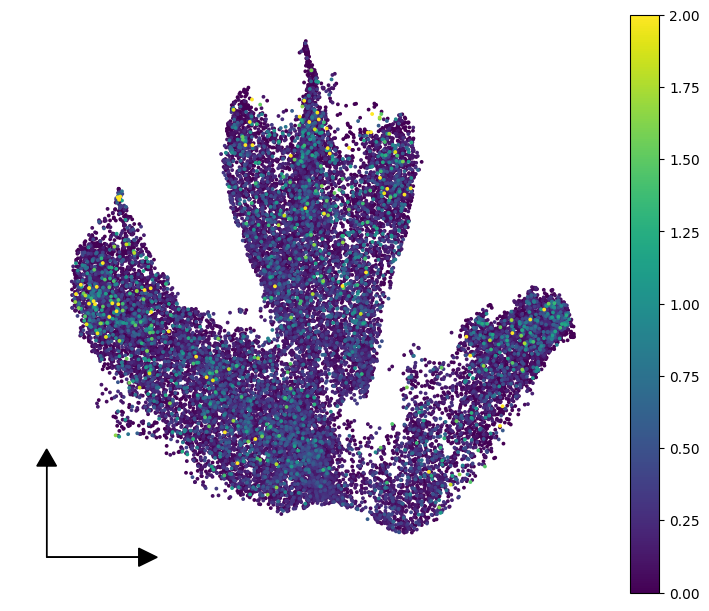

In [47]:
scit.pl.embedding2d(adata2, 'X_umap', 'copied_data', vminmax=(0,2))

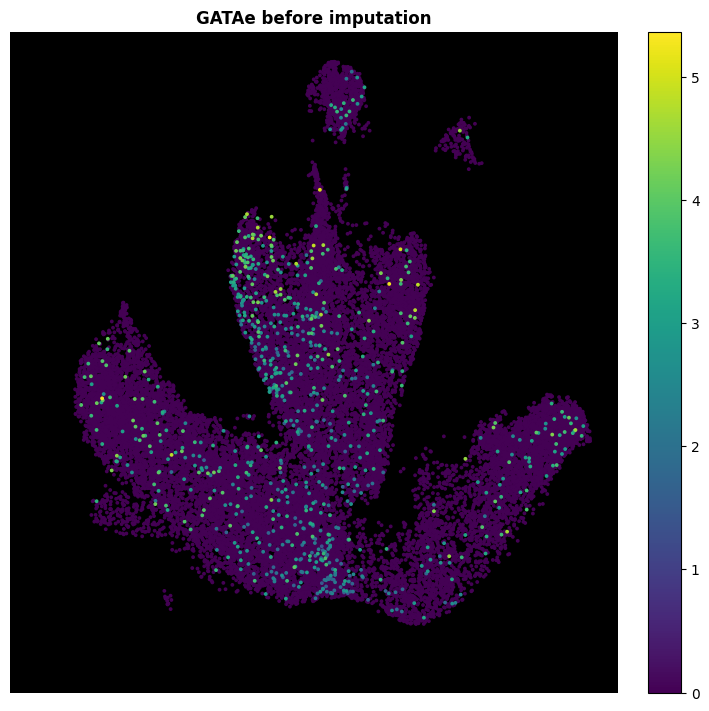

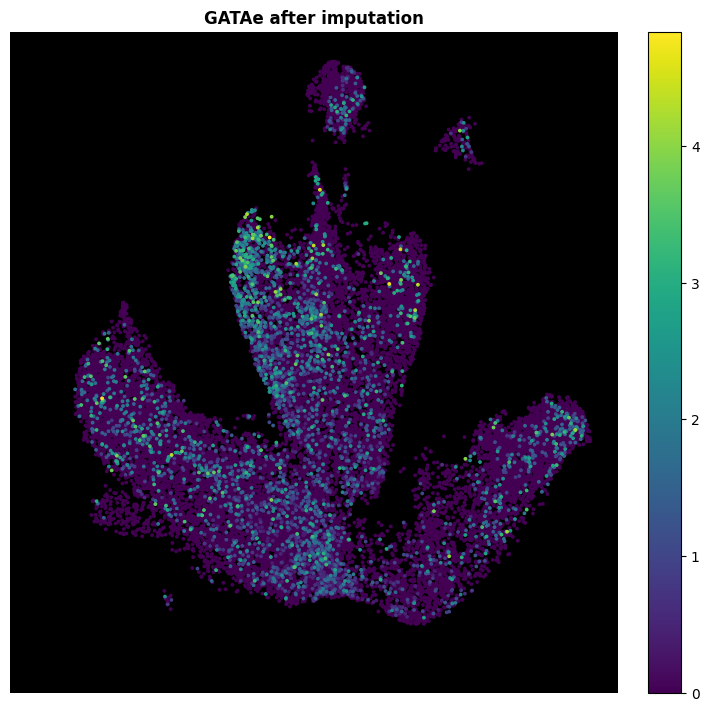

In [ ]:
pre_imp_acet = scit.tl.make_layer_config('acet', log_transform=True,
                                         normalize_with_obs_counts=True, feature_names=ctad.var_names)
imputed_acet = scit.tl.make_layer_config('imputed_acet', log_transform=True,
                                         normalize_with_obs_counts=True, feature_names=ctad.var_names)

# Change var index to find a suitable var as an example
# var_index = 'chr3R:7085000-7090000'
var_index = 'chr3R:16005000-16010000' #GATAe
# var_index = 'chrX:520000-525000' #elav
# var_index = 'chrX:535000-540000' #elav2

scit.tl.layer_pick_features(ctad, pre_imp_acet, var_index)
scit.tl.copy_to_obs(ctad, pre_imp_acet)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = 'GATAe before imputation')

scit.tl.layer_pick_features(ctad, imputed_acet, var_index)
scit.tl.copy_to_obs(ctad, imputed_acet)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = 'GATAe after imputation')